In [174]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import time
from math import sqrt

In [175]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBALS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [176]:
def met_diag(L,N,V,hbar,m,k):
    t0 = time.time()
    dx=L/N
    t=hbar**2/(2*m*dx*dx)
    H=np.zeros((N-2)**2).reshape((N-2,N-2))
    for i in range(N-2):
        H[i][i]=2*t
    for i in range(N-3):
        H[i+1][i]=-t
        H[i][i+1]=-t
    eigvals, eigvecs = np.linalg.eigh(H)
    keigvals = np.zeros(k)
    keigvecs = np.zeros(k*(N)).reshape((k,N))

    print(np.shape(keigvecs))

    for i in range(k):
        keigvals[i] = eigvals[i]
        keigvecs[i, 1:-1] = eigvecs[i, :]
    t1=time.time()
    return keigvals, keigvecs, t1-t0
    # print(f"Czas metody diagonalizacji: {t1-t0}")


In [177]:
# parametry
L=5
N=400
V0=1

hbar=1
m=1

In [178]:
# inicjalizacja
x = np.linspace(-L/2,L/2,N)
V = V0*(x-L/2)*(x-L/2)*0
n = [1,3,12,19]
n=np.subtract(n,1)
# print(n)

In [179]:
# diagonalizacja
diag_evals, diag_evecs, diag_czas = met_diag(L,N,V,hbar,m,k=max(n)+1)
print(f'Czas diagonalizacji: {diag_czas:.4f}s')
# print(diag_evecs)

(19, 400)
Czas diagonalizacji: 0.1184s


In [185]:
apsi1 = sqrt(2/L)*np.cos((n[0]+1)*np.pi*x/L)
apsi3 = sqrt(2/L)*np.cos((n[1]+1)*np.pi*x/L)
apsi12 = sqrt(2/L)*np.sin((n[2]+1)*np.pi*x/L)
apsi19 = sqrt(2/L)*np.cos((n[3]+1)*np.pi*x/L)

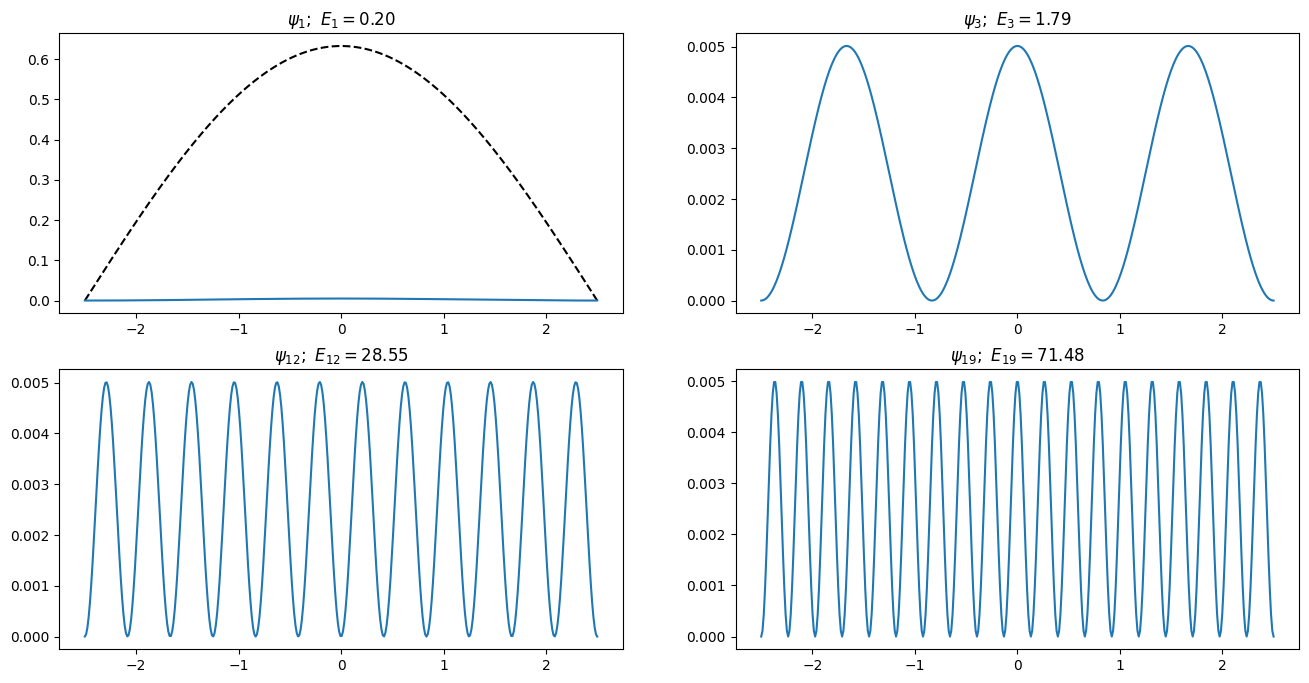

In [186]:
# wykres
fig, axs = plt.subplots(2,2,figsize=(16,8))

k=n[0]
axs[0,0].plot(x,apsi1,linestyle='--',color='black')
axs[0,0].plot(x,np.abs(diag_evecs[k,:])**2,label=rf'$E_{{{k+1}}}={diag_evals[k]:.2f}$')
axs[0,0].set_title(rf'$\psi_{{{k+1}}};\ E_{{{k+1}}}={diag_evals[k]:.2f}$')

k=n[1]
axs[0,1].plot(x,np.abs(diag_evecs[k,:])**2,label=rf'$E_{{{k+1}}}={diag_evals[k]:.2f}$')
axs[0,1].set_title(rf'$\psi_{{{k+1}}};\ E_{{{k+1}}}={diag_evals[k]:.2f}$')

k=n[2]
axs[1,0].plot(x,np.abs(diag_evecs[k,:])**2,label=rf'$E_{{{k+1}}}={diag_evals[k]:.2f}$')
axs[1,0].set_title(rf'$\psi_{{{k+1}}};\ E_{{{k+1}}}={diag_evals[k]:.2f}$')

k=n[3]
axs[1,1].plot(x,np.abs(diag_evecs[k,:])**2,label=rf'$E_{{{k+1}}}={diag_evals[k]:.2f}$')
axs[1,1].set_title(rf'$\psi_{{{k+1}}};\ E_{{{k+1}}}={diag_evals[k]:.2f}$')

# for k in n:
#     plt.plot(x,np.abs(diag_evecs[k,:])**2,label=rf'$E_{{{k+1}}}={diag_evals[k]:.2f}$')
#     plt.legend()
plt.show()

In [182]:
# porównanie
E_analiticzne = np.pi*np.pi*hbar*hbar/(2*m*L*L)*np.pow(np.add(n,1),2)
E_wyznaczone = [diag_evals[n[0]], diag_evals[n[1]], diag_evals[n[2]], diag_evals[n[3]]]
bl_bzw = np.abs(E_analiticzne-E_wyznaczone)
bl_wz = bl_bzw/E_analiticzne
print(f'Energie analityczne: {E_analiticzne}')
print(f'Energie numeryczne: {E_wyznaczone}')
print(f'Błędy bezwzględne: {bl_bzw}')
print(f'Błędy względne: {bl_wz}')

Energie analityczne: [ 0.19739209  1.77652879 28.42446068 71.25854378]
Energie numeryczne: [np.float64(0.19838173704947376), np.float64(1.7853618430211646), np.float64(28.545871953382765), np.float64(71.4827121591752)]
Błędy bezwzględne: [0.00098965 0.00883305 0.12141128 0.22416838]
Błędy względne: [0.00501362 0.00497208 0.00427137 0.00314585]
